# 02_data_audit.ipynb

1. Dataset structure
2. Dimensions
3. Coordinates
4. Variables
5. Attributes
6. Spatial coverage
7. Temporal coverage
8. Resolution
9. Units
10. Missing values
11. Valid ranges
12. Basic statistics
13. Simple spatial plots
14. Compare datasets

In [24]:
import xarray as xr 

ds_sst=xr.open_dataset("../data/raw/sst/sst_bob.nc")
ds_ssh=xr.open_dataset("../data/raw/ssh/ssh_bob.nc")
ds_glorys=xr.open_dataset("../data/raw/glorys/glorys_bob.nc")
ds_winds=xr.open_dataset("../data/raw/winds/winds_bob.nc")
ds_currents=xr.open_dataset("../data/raw/currents/currents_bob.nc")
ds_sss_asc=xr.open_dataset("../data/raw/sss/sss_bob_ascending.nc")
ds_sss_desc=xr.open_dataset("../data/raw/sss/sss_bob_descending.nc")



## 1.SST Dataset

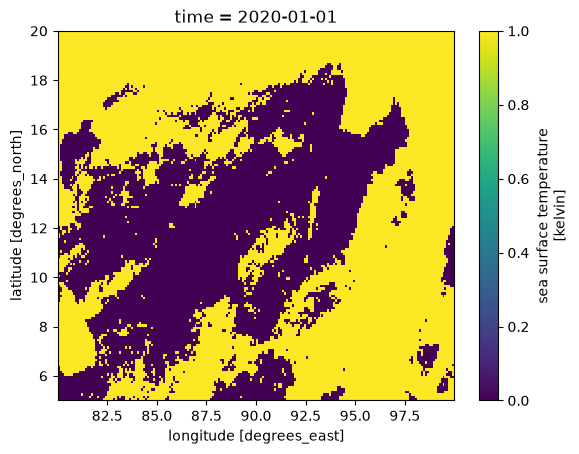

In [64]:
sst.isnull().isel(time=0).plot()

In [12]:
def spatial_coverage(ds, name):
    lat = ds["latitude"]
    lon = ds["longitude"]

    print(f"\n{name}")
    print("-" * 40)
    print(f"Latitude:  {lat.min().item():.4f} to {lat.max().item():.4f}")
    print(f"Longitude: {lon.min().item():.4f} to {lon.max().item():.4f}")

In [52]:
print("Spatial Coverage of Datasets")
print("=" * 40)
print(spatial_coverage(ds_sst, "SST"))
print(spatial_coverage(ds_ssh, "SSH"))
print(spatial_coverage(ds_glorys, "GLORYS"))
print(spatial_coverage(ds_winds, "Winds"))
print(spatial_coverage(ds_currents, "Currents"))
print(spatial_coverage(ds_sss_asc, "SSS Ascending"))
print(spatial_coverage(ds_sss_desc, "SSS Descending"))

Spatial Coverage of Datasets

SST
----------------------------------------
Latitude:  5.0500 to 19.9500
Longitude: 80.0500 to 99.9500
None

SSH
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750
None

GLORYS
----------------------------------------
Latitude:  5.0000 to 20.0000
Longitude: 80.0000 to 100.0000
None

Winds
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750
None

Currents
----------------------------------------
Latitude:  5.1250 to 19.8750
Longitude: 80.1250 to 99.8750
None

SSS Ascending
----------------------------------------
Latitude:  5.0000 to 19.8000
Longitude: 80.2000 to 100.0000
None

SSS Descending
----------------------------------------
Latitude:  5.0000 to 19.8000
Longitude: 80.2000 to 100.0000
None


In [13]:
def temporal_coverage(ds, name):
    time = ds["time"]

    print(f"\n{name}")
    print("-" * 40)
    print(f"Time: {time.min().item()} to {time.max().item()}")

In [53]:
print("\nTemporal Coverage of Datasets")
print("=" * 40)
print(temporal_coverage(ds_sst, "SST"))
print(temporal_coverage(ds_ssh, "SSH"))
print(temporal_coverage(ds_glorys, "GLORYS"))
print(temporal_coverage(ds_winds, "Winds"))
print(temporal_coverage(ds_currents, "Currents"))
print(temporal_coverage(ds_sss_asc, "SSS Ascending"))
print(temporal_coverage(ds_sss_desc, "SSS Descending"))


Temporal Coverage of Datasets

SST
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

SSH
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

GLORYS
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

Winds
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

Currents
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

SSS Ascending
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None

SSS Descending
----------------------------------------
Time: 1577836800000000000 to 1577836800000000000
None


In [14]:
def dataset_review(ds, name):
    print(f"\n{name}")
    print(ds.dims)
    print(ds.coords)
    print(ds.data_vars)
    print(ds.attrs)

In [54]:
print("\nDataset Review")
print("=" * 40)
print(dataset_review(ds_sst, "SST"))
print(dataset_review(ds_ssh, "SSH"))
print(dataset_review(ds_glorys, "GLORYS"))
print(dataset_review(ds_winds, "Winds"))
print(dataset_review(ds_currents, "Currents"))
print(dataset_review(ds_sss_asc, "SSS Ascending"))
print(dataset_review(ds_sss_desc, "SSS Descending"))


Dataset Review
FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 150, 'longitude': 200})
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-01-01
  * latitude   (latitude) float64 1kB 5.05 5.15 5.25 5.35 ... 19.75 19.85 19.95
  * longitude  (longitude) float64 2kB 80.05 80.15 80.25 ... 99.75 99.85 99.95
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float64 240kB ...
{'Conventions': 'CF-1.7,ACDD-1.3,ISO 8601', 'acknowledgment': 'Please acknowledge the use of these data with the following statement: these data were obtained from Copernicus Marine Service and produced by the Centre de Recherche et d Exploitation Satellitaire (CERSAT), at Ifremer, Plouzane (France', 'cdm_data_type': 'grid', 'cmems_product_id': 'SST_GLO_PHY_L3S_MY_010_039', 'comment': 'WARNING:Some applications are unable to properly handle signed byte values. If values are encountered > 127, please substract 256 from this reported value', 'contact': 'jean.francois.piolle@ifremer.

In [ ]:
def data_array_review(ds, name):
    print(f"\n{name}")
    da=ds[name]
    print(da.dims)
    print(da.coords)
    print(da.attrs)

In [55]:
print("\nDataset Data Array Names")
print("=" * 40) 
print(ds_sst.data_vars)
print(ds_ssh.data_vars)
print(ds_glorys.data_vars)
print(ds_winds.data_vars)
print(ds_currents.data_vars)
print(ds_sss_asc.data_vars)
print(ds_sss_desc.data_vars)


Dataset Data Array Names
Data variables:
    sea_surface_temperature  (time, latitude, longitude) float64 240kB ...
Data variables:
    sla      (time, latitude, longitude) float64 38kB ...
Data variables:
    thetao   (time, depth, latitude, longitude) float64 13MB ...
Data variables:
    eastward_wind   (time, latitude, longitude) float64 38kB ...
    northward_wind  (time, latitude, longitude) float64 38kB ...
Data variables:
    uo       (time, depth, latitude, longitude) float64 38kB ...
    vo       (time, depth, latitude, longitude) float64 38kB ...
Data variables:
    Sea_Surface_Salinity  (time, latitude, longitude) float32 30kB ...
Data variables:
    Sea_Surface_Salinity  (time, latitude, longitude) float32 30kB ...


In [57]:
print("\nData Array Review")
print("=" * 40)
print(data_array_review(ds_sst, "sea_surface_temperature"))
print(data_array_review(ds_ssh, "sla"))  
print(data_array_review(ds_glorys, "thetao"))
print(data_array_review(ds_winds, "eastward_wind"))
print(data_array_review(ds_winds, "northward_wind"))
print(data_array_review(ds_currents, "uo"))
print(data_array_review(ds_currents, "vo"))
print(data_array_review(ds_sss_asc, "Sea_Surface_Salinity"))
print(data_array_review(ds_sss_desc, "Sea_Surface_Salinity"))


Data Array Review

sea_surface_temperature
('time', 'latitude', 'longitude')
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-01-01
  * latitude   (latitude) float64 1kB 5.05 5.15 5.25 5.35 ... 19.75 19.85 19.95
  * longitude  (longitude) float64 2kB 80.05 80.15 80.25 ... 99.75 99.85 99.95
{'authority': 'CF-1.7', 'long_name': 'sea surface temperature', 'standard_name': 'sea_surface_foundation_temperature', 'type': 'foundation', 'units': 'kelvin', 'valid_max': np.int16(4500), 'valid_min': np.int16(-300)}
None

sla
('time', 'latitude', 'longitude')
Coordinates:
  * time       (time) datetime64[ns] 8B 2020-01-01
  * latitude   (latitude) float32 240B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float32 320B 80.12 80.38 80.62 ... 99.38 99.62 99.88
{'ancillary_variables': 'err_sla', 'comment': 'The sea level anomaly is the sea surface height above mean sea surface; it is referenced to the [1993, 2012] period; see the product user manual for details', 'grid_ma

In [16]:
def data_array_statistics(ds, name):
    print(f"\n{name}")
    da=ds[name]
    print("-" * 40)
    print(da.attrs["units"]) #this is in kelvin,we need it in celcius
    print(da.min().item())
    print(da.max().item())
    print(da.mean().item())
    print(da.std().item())

In [58]:
print("\nData Array Statistics")
print("=" * 40)
print(data_array_statistics(ds_sst, "sea_surface_temperature"))
print(data_array_statistics(ds_ssh, "sla"))
print(data_array_statistics(ds_glorys, "thetao"))
print(data_array_statistics(ds_winds, "eastward_wind"))
print(data_array_statistics(ds_winds, "northward_wind"))
print(data_array_statistics(ds_currents, "uo"))
print(data_array_statistics(ds_currents, "vo"))
print(data_array_statistics(ds_sss_asc, "Sea_Surface_Salinity"))
print(data_array_statistics(ds_sss_desc, "Sea_Surface_Salinity"))


Data Array Statistics

sea_surface_temperature
----------------------------------------
kelvin
296.94
302.53
300.95572722937527
0.7671907922021359
None

sla
----------------------------------------
m
-0.1836
0.2554
0.01947384196185286
0.07346163691019743
None

thetao
----------------------------------------
degrees_C
5.63771478831768
32.01596117019653
21.752516799332742
7.792001327286843
None

eastward_wind
----------------------------------------
m s-1
-10.040000000000001
1.95
-5.482898113207547
2.0698738766144134
None

northward_wind
----------------------------------------
m s-1
-7.9
2.48
-1.497388679245283
1.7186930016248116
None

uo
----------------------------------------
m/s
-0.9440000000000001
0.7000000000000001
-0.16250808729139923
0.20125838104858615
None

vo
----------------------------------------
m/s
-0.551
0.685
0.06933632862644416
0.18596037606397092
None

Sea_Surface_Salinity
----------------------------------------
0.001
26.159183502197266
40.67074966430664
31.8706951

In [18]:
def missing_value_audit(ds, name):
    print(f"\n{name}")
    print("-" * 50)

    for var_name, var in ds.data_vars.items():
        missing_count = var.isnull().sum().item()
        total_count = var.size
        # Calculate the percentage of missing values
        missing_percent = (missing_count / total_count) * 100

        print(f"{var_name}")
        print(f"  Total values:   {total_count:,}")
        print(f"  Missing values: {missing_count:,}")
        print(f"  Missing %:      {missing_percent:.4f}%")

In [59]:
print("\nMissing Value Audit")
print("=" * 50)
print(missing_value_audit(ds_sst, "SST"))
print(missing_value_audit(ds_ssh, "SSH"))
print(missing_value_audit(ds_glorys, "GLORYS"))
print(missing_value_audit(ds_winds, "Winds"))
print(missing_value_audit(ds_currents, "Currents"))
print(missing_value_audit(ds_sss_asc, "SSS Ascending"))
print(missing_value_audit(ds_sss_desc, "SSS Descending"))



Missing Value Audit

SST
--------------------------------------------------
sea_surface_temperature
  Total values:   30,000
  Missing values: 17,418
  Missing %:      58.0600%
None

SSH
--------------------------------------------------
sla
  Total values:   4,800
  Missing values: 763
  Missing %:      15.8958%
None

GLORYS
--------------------------------------------------
thetao
  Total values:   1,570,356
  Missing values: 415,297
  Missing %:      26.4460%
None

Winds
--------------------------------------------------
eastward_wind
  Total values:   4,800
  Missing values: 3,475
  Missing %:      72.3958%
northward_wind
  Total values:   4,800
  Missing values: 3,475
  Missing %:      72.3958%
None

Currents
--------------------------------------------------
uo
  Total values:   4,800
  Missing values: 905
  Missing %:      18.8542%
vo
  Total values:   4,800
  Missing values: 905
  Missing %:      18.8542%
None

SSS Ascending
--------------------------------------------------
S

In [19]:
def spatial_resolution(ds, name):
    lat = ds["latitude"]
    lon = ds["longitude"]

    lat_diff = lat.diff("latitude")
    lon_diff = lon.diff("longitude")

    print(f"\n{name}")
    print("-" * 40)
    print(f"Latitude spacing:  {lat_diff.min().item():.6f} to {lat_diff.max().item():.6f}")
    print(f"Longitude spacing: {lon_diff.min().item():.6f} to {lon_diff.max().item():.6f}")

In [60]:
print("\nSpatial Resolution of Datasets")
print("=" * 40)
print(spatial_resolution(ds_sst, "SST"))
print(spatial_resolution(ds_ssh, "SSH"))
print(spatial_resolution(ds_glorys, "GLORYS"))
print(spatial_resolution(ds_winds, "Winds"))
print(spatial_resolution(ds_currents, "Currents"))
print(spatial_resolution(ds_sss_asc, "SSS Ascending"))
print(spatial_resolution(ds_sss_desc, "SSS Descending"))


Spatial Resolution of Datasets

SST
----------------------------------------
Latitude spacing:  0.099998 to 0.100000
Longitude spacing: 0.099998 to 0.100006
None

SSH
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

GLORYS
----------------------------------------
Latitude spacing:  0.083332 to 0.083334
Longitude spacing: 0.083328 to 0.083336
None

Winds
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

Currents
----------------------------------------
Latitude spacing:  0.250000 to 0.250000
Longitude spacing: 0.250000 to 0.250000
None

SSS Ascending
----------------------------------------
Latitude spacing:  0.200000 to 0.200000
Longitude spacing: 0.200000 to 0.200000
None

SSS Descending
----------------------------------------
Latitude spacing:  0.200000 to 0.200000
Longitude spacing: 0.200000 to 0.200000
None


In [20]:
import matplotlib.pyplot as plt

In [21]:
def plot_spatial(da, name, time_index=0, depth_index=None):
    if "time" in da.dims:
        da = da.isel(time=time_index)

    if depth_index is not None and "depth" in da.dims:
        da = da.isel(depth=depth_index)

    plt.figure(figsize=(8, 5))
    da.plot()
    plt.title(name)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

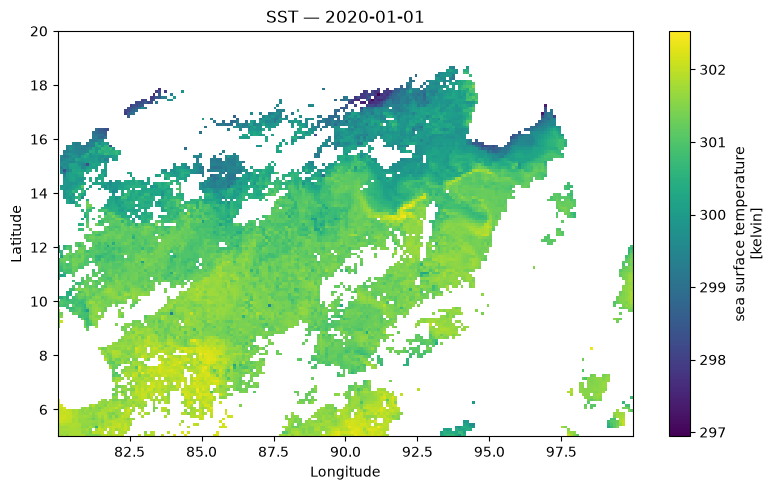

In [26]:
plot_spatial(
    ds_sst["sea_surface_temperature"],
    "SST — 2020-01-01"
)

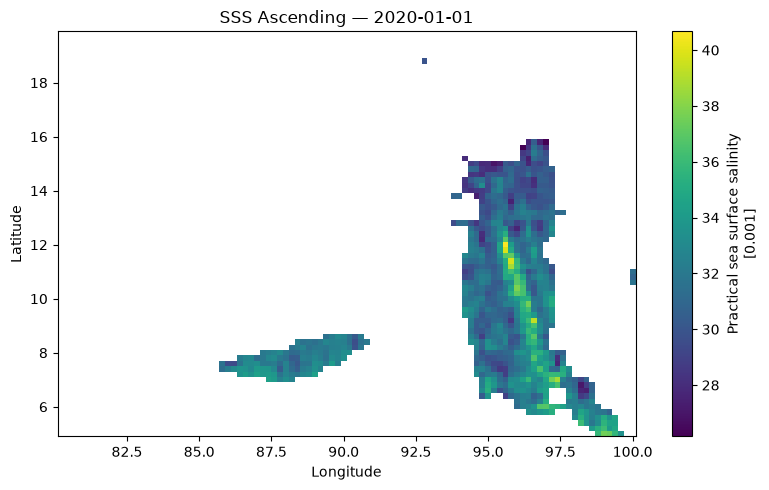

In [27]:
plot_spatial(
    ds_sss_asc["Sea_Surface_Salinity"],
    "SSS Ascending — 2020-01-01"
)

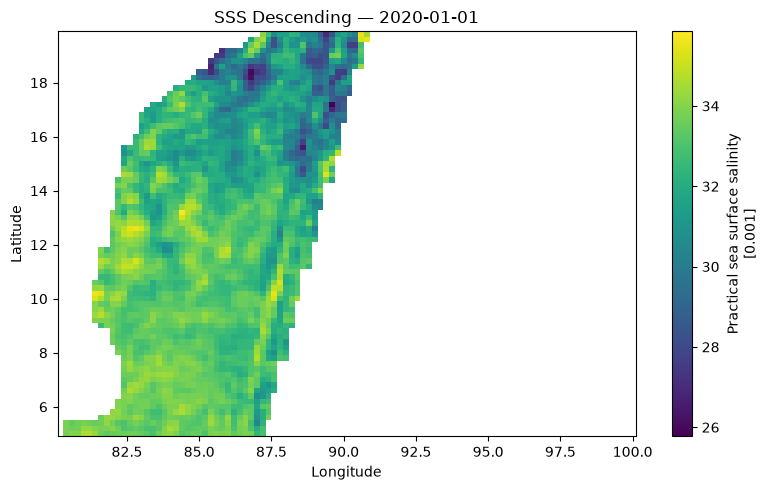

In [28]:
plot_spatial(
    ds_sss_desc["Sea_Surface_Salinity"],
    "SSS Descending — 2020-01-01"
)

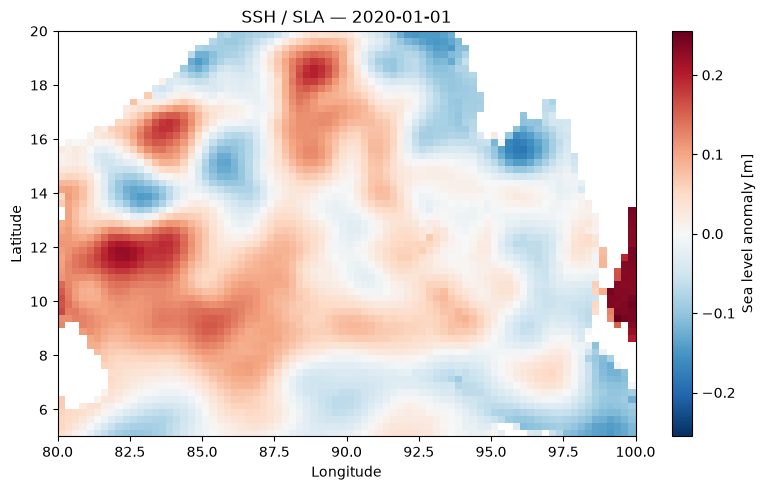

In [29]:
plot_spatial(
    ds_ssh["sla"],
    "SSH / SLA — 2020-01-01"
)

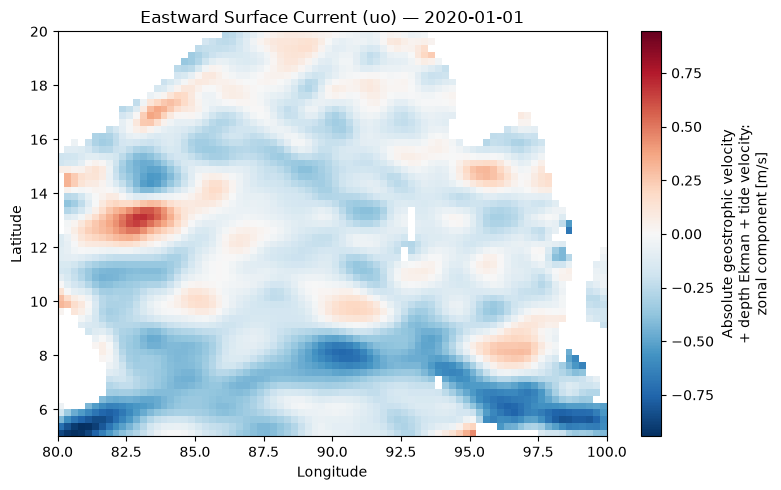

In [31]:
plot_spatial(
    ds_currents["uo"],
    "Eastward Surface Current (uo) — 2020-01-01"
)

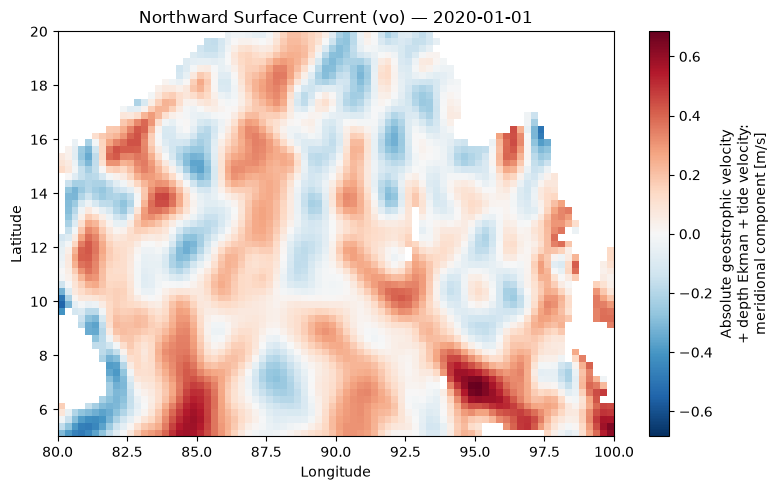

In [33]:
plot_spatial(
    ds_currents["vo"],
    "Northward Surface Current (vo) — 2020-01-01"
)

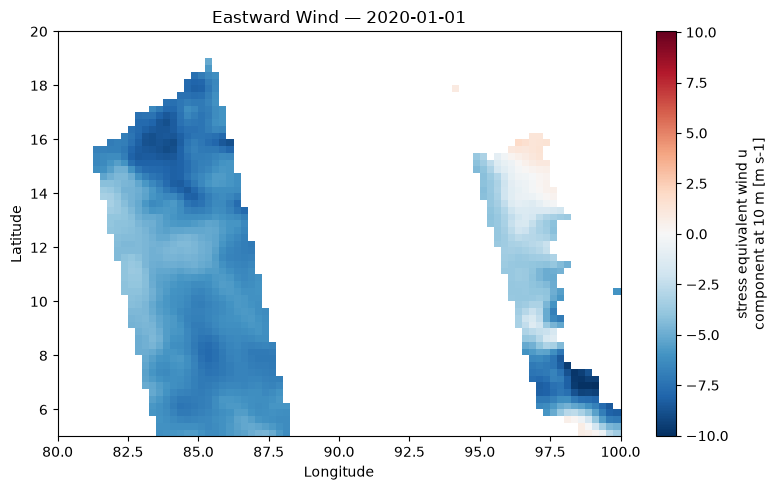

In [35]:
plot_spatial(
    ds_winds["eastward_wind"],
    "Eastward Wind — 2020-01-01"
)

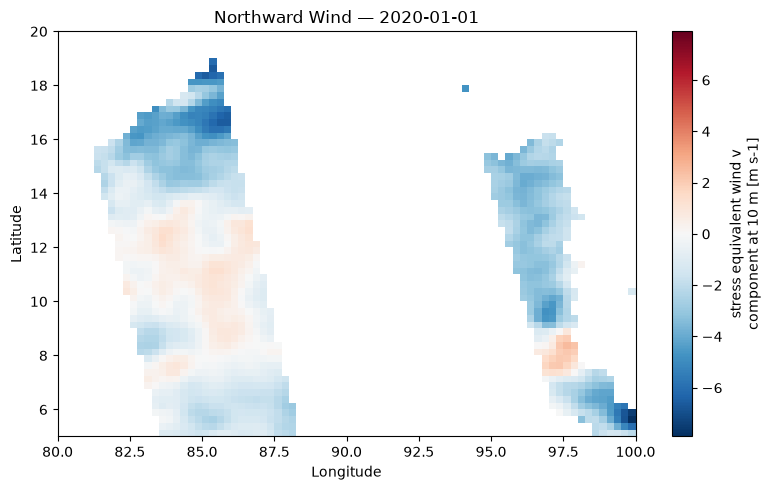

In [36]:
plot_spatial(
    ds_winds["northward_wind"],
    "Northward Wind — 2020-01-01"
)

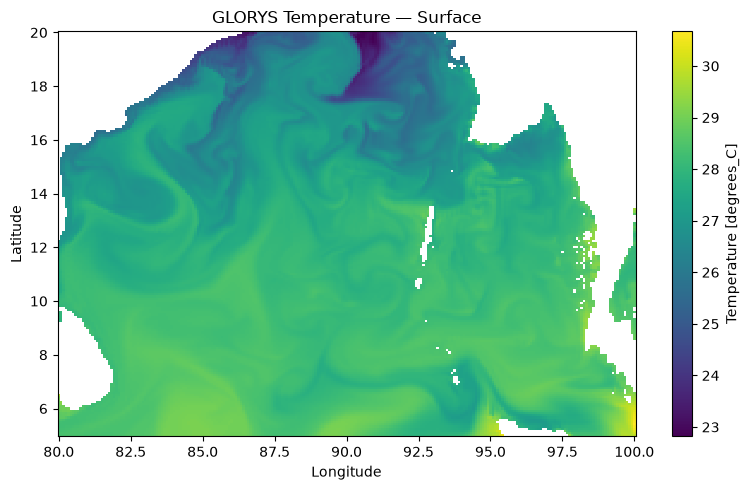

In [37]:
plot_spatial(
    ds_glorys["thetao"],
    "GLORYS Temperature — Surface",
    depth_index=0
)

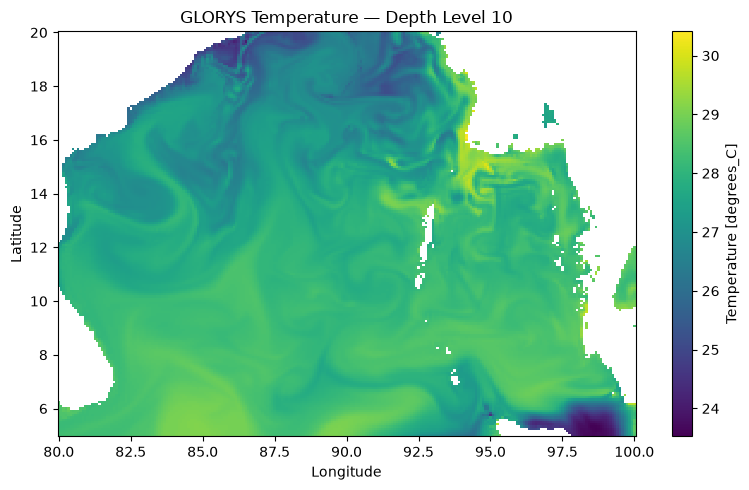

In [38]:
plot_spatial(
    ds_glorys["thetao"],
    "GLORYS Temperature — Depth Level 10",
    depth_index=10
)

In [22]:
def compare_grid(ds, name):
    lat = ds["latitude"]
    lon = ds["longitude"]

    lat_spacing = lat.diff("latitude")
    lon_spacing = lon.diff("longitude")

    print(f"\n{name}")
    print("-" * 60)
    print(f"Latitude:  {lat.min().item():.4f} → {lat.max().item():.4f}")
    print(f"Longitude: {lon.min().item():.4f} → {lon.max().item():.4f}")
    print(f"Shape:     {lat.size} × {lon.size}")
    print(f"Lat step:  {lat_spacing.mean().item():.6f}°")
    print(f"Lon step:  {lon_spacing.mean().item():.6f}°")

In [61]:
print("\nGrid Comparison of Datasets")
compare_grid(ds_sst, "SST")
compare_grid(ds_sss_asc, "SSS Ascending")
compare_grid(ds_sss_desc, "SSS Descending")
compare_grid(ds_ssh, "SSH")
compare_grid(ds_currents, "Currents")
compare_grid(ds_winds, "Winds")
compare_grid(ds_glorys, "GLORYS")


Grid Comparison of Datasets

SST
------------------------------------------------------------
Latitude:  5.0500 → 19.9500
Longitude: 80.0500 → 99.9500
Shape:     150 × 200
Lat step:  0.100000°
Lon step:  0.100000°

SSS Ascending
------------------------------------------------------------
Latitude:  5.0000 → 19.8000
Longitude: 80.2000 → 100.0000
Shape:     75 × 100
Lat step:  0.200000°
Lon step:  0.200000°

SSS Descending
------------------------------------------------------------
Latitude:  5.0000 → 19.8000
Longitude: 80.2000 → 100.0000
Shape:     75 × 100
Lat step:  0.200000°
Lon step:  0.200000°

SSH
------------------------------------------------------------
Latitude:  5.1250 → 19.8750
Longitude: 80.1250 → 99.8750
Shape:     60 × 80
Lat step:  0.250000°
Lon step:  0.250000°

Currents
------------------------------------------------------------
Latitude:  5.1250 → 19.8750
Longitude: 80.1250 → 99.8750
Shape:     60 × 80
Lat step:  0.250000°
Lon step:  0.250000°

Winds
------------

In [39]:
def compare_time(ds, name):
    time = ds["time"]

    print(
        f"{name:20s} | "
        f"start={time.min().values} | "
        f"end={time.max().values} | "
        f"count={time.size}"
    )

In [41]:
compare_time(ds_sst, "SST")
compare_time(ds_sss_asc, "SSS Asc")
compare_time(ds_sss_desc, "SSS Desc")
compare_time(ds_ssh, "SSH")
compare_time(ds_currents, "Currents")
compare_time(ds_winds, "Winds")
compare_time(ds_glorys, "GLORYS")

SST                  | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
SSS Asc              | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
SSS Desc             | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
SSH                  | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
Currents             | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
Winds                | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1
GLORYS               | start=2020-01-01T00:00:00.000000000 | end=2020-01-01T00:00:00.000000000 | count=1


In [43]:
datasets = {
    "SST": ds_sst,
    "SSS Asc": ds_sss_asc,
    "SSS Desc": ds_sss_desc,
    "SSH": ds_ssh,
    "Currents": ds_currents,
    "Winds": ds_winds,
    "GLORYS": ds_glorys,
}

In [44]:
for name, ds in datasets.items():
    lat = ds["latitude"]
    lon = ds["longitude"]

    print(
        f"{name:12s} | "
        f"lat {lat.min().item():.3f} → {lat.max().item():.3f} | "
        f"lon {lon.min().item():.3f} → {lon.max().item():.3f}"
    )

SST          | lat 5.050 → 19.950 | lon 80.050 → 99.950
SSS Asc      | lat 5.000 → 19.800 | lon 80.200 → 100.000
SSS Desc     | lat 5.000 → 19.800 | lon 80.200 → 100.000
SSH          | lat 5.125 → 19.875 | lon 80.125 → 99.875
Currents     | lat 5.125 → 19.875 | lon 80.125 → 99.875
Winds        | lat 5.125 → 19.875 | lon 80.125 → 99.875
GLORYS       | lat 5.000 → 20.000 | lon 80.000 → 100.000


### SSS ascending VS descending

In [45]:
sss_asc = ds_sss_asc["Sea_Surface_Salinity"]
sss_desc = ds_sss_desc["Sea_Surface_Salinity"]

In [46]:
print(sss_asc.dims)
print(sss_desc.dims)

print(sss_asc.latitude.equals(sss_desc.latitude))
print(sss_asc.longitude.equals(sss_desc.longitude))  #we observe the coordinates are identical
print(sss_asc.time.equals(sss_desc.time))

('time', 'latitude', 'longitude')
('time', 'latitude', 'longitude')
True
True
True


In [63]:
sss_difference = sss_asc - sss_desc
print("sss difference")
print(sss_difference.min().item())
print(sss_difference.max().item())
print(sss_difference.mean().item())

sss difference
-3.3704566955566406
2.0812034606933594
-0.02941579557955265


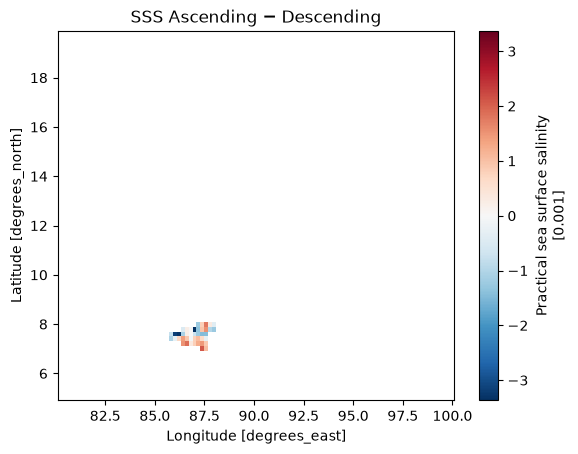

In [50]:
sss_difference.isel(time=0).plot()
plt.title("SSS Ascending − Descending")
plt.show()

In [51]:
print("SST vs SSH latitude:",
      ds_sst.latitude.equals(ds_ssh.latitude)) #it shows false,this is what we need to solve in preprocessing

print("SST vs SSH longitude:",
      ds_sst.longitude.equals(ds_ssh.longitude))

SST vs SSH latitude: False
SST vs SSH longitude: False
